# Tahap 1 � Dataset dan Preprocessing (PRDECT-ID)
Tujuan dari notebook ini adalah untuk menyiapkan dataset berkualitas tinggi dari PRDECT-ID untuk digunakan dalam eksperimen **emotion classification**. Seluruh proses didokumentasikan dengan visualisasi dan tabel komparasi sebagai bahan laporan skripsi.

## 1. Konfigurasi & Import Library
Mendefinisikan parameter global dan library yang diperlukan.

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

# Global Configuration
RANDOM_STATE = 42
TEST_SIZE = 0.2
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN = 128

# Path Configuration (Colab & Local Friendly)
import os
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Mounting Drive...")
    drive.mount('/content/drive')
    # Update this to match your Google Drive project path
    BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
else:
    print("Running locally.")
    BASE_PATH = ".." # Assuming running from notebooks/ folder

RAW_DATA_PATH = f"{BASE_PATH}/data/raw/PRDECT-ID Dataset.csv"
PROCESSED_DIR = f"{BASE_PATH}/data/processed"

print(f"Eksperimen dimulai pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Running in Google Colab. Mounting Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Eksperimen dimulai pada: 2026-05-11 19:16:57


## 2. Load Dataset
Membaca dataset asli PRDECT-ID.

In [3]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print(f"Dataset berhasil dimuat: {RAW_DATA_PATH}")
df_raw.head()

Dataset berhasil dimuat: /content/drive/MyDrive/xai_lime_vs_shap/data/raw/PRDECT-ID Dataset.csv


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


## 3. Dataset Metadata Summary
Memberikan gambaran umum mengenai statistik data awal.

In [4]:
print("=== Dataset Metadata ===")
print(f"Jumlah Baris: {df_raw.shape[0]}")
print(f"Jumlah Kolom: {df_raw.shape[1]}")
print(f"Daftar Kolom: {df_raw.columns.tolist()}")
print(f"Jumlah Kelas (Emotion): {df_raw['Emotion'].nunique()}")
print("-" * 30)
print("Missing Value Summary:")
print(df_raw.isna().sum())
print("-" * 30)
print(f"Jumlah Data Duplikat: {df_raw.duplicated().sum()}")

=== Dataset Metadata ===
Jumlah Baris: 5400
Jumlah Kolom: 11
Daftar Kolom: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']
Jumlah Kelas (Emotion): 5
------------------------------
Missing Value Summary:
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64
------------------------------
Jumlah Data Duplikat: 7


## 4. Seleksi Kolom
Hanya mengambil kolom `Customer Review` dan `Emotion`.

**Rationale**: Kolom lain seperti Category, Price, dan Rating tidak relevan terhadap tugas klasifikasi emosi dan berpotensi menjadi noise bagi model.

In [5]:
df = df_raw[['Customer Review', 'Emotion']].copy()
print(f"Shape setelah seleksi kolom: {df.shape}")
df.head()

Shape setelah seleksi kolom: (5400, 2)


,Customer Review,Emotion
0,Alhamdulillah berfungsi dengan baik. Packaging...,Happy
1,"barang bagus dan respon cepat, harga bersaing ...",Happy
2,"barang bagus, berfungsi dengan baik, seler ram...",Happy
3,bagus sesuai harapan penjual nya juga ramah. t...,Happy
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Happy


## 5. Pembersihan Data Duplikat & Missing Values

In [6]:
# Hapus Duplikat
initial_count = len(df)
df = df.drop_duplicates().reset_index(drop=True)
duplicates_removed = initial_count - len(df)
print(f"Jumlah duplikat dihapus: {duplicates_removed}")

# Hapus Missing Values
df = df.dropna().reset_index(drop=True)
print(f"Jumlah baris setelah pembersihan: {len(df)}")

Jumlah duplikat dihapus: 70
Jumlah baris setelah pembersihan: 5330


## 6. Preprocessing Design Decision
Pada eksperimen ini, **Stemming** dan **Stopword Removal** sengaja **TIDAK** dilakukan.

**Alasan**: Model berbasis Transformer seperti **IndoBERT** dilatih untuk memahami konteks dalam urutan kalimat yang utuh. Menghapus stopword atau mengubah kata ke bentuk dasarnya dapat menghilangkan informasi semantik dan sintaksis yang krusial bagi pemahaman konteks emosi oleh model.

## 7. Cleaning Text
Proses pembersihan teks meliputi: lowercase, penghapusan tanda baca, karakter khusus, dan normalisasi spasi.

In [7]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation & special characters
    # Menggunakan regex untuk menghapus tanda baca dan karakter selain alfanumerik dan spasi
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Simpan teks asli untuk perbandingan
df['Review_Original'] = df['Customer Review']
df['Customer Review'] = df['Customer Review'].apply(clean_text)

# Tabel Komparasi Before vs After untuk Skripsi
print("Tabel Komparasi Pembersihan Teks (5 Sampel):")
df[['Review_Original', 'Customer Review']].head(5)

Tabel Komparasi Pembersihan Teks (5 Sampel):


,Review_Original,Customer Review
0,Alhamdulillah berfungsi dengan baik. Packaging...,alhamdulillah berfungsi dengan baik packaging ...
1,"barang bagus dan respon cepat, harga bersaing ...",barang bagus dan respon cepat harga bersaing d...
2,"barang bagus, berfungsi dengan baik, seler ram...",barang bagus berfungsi dengan baik seler ramah...
3,bagus sesuai harapan penjual nya juga ramah. t...,bagus sesuai harapan penjual nya juga ramah tr...
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",barang bagus pengemasan aman dapat berfungsi d...


## 8. Encode Label
Mengubah label teks menjadi representasi numerik.

Label Mapping:


,Label,Encoding
0,Anger,0
1,Fear,1
2,Happy,2
3,Love,3
4,Sadness,4


/tmp/ipykernel_13140/1986094605.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Emotion', palette='viridis', order=df['Emotion'].value_counts().index)


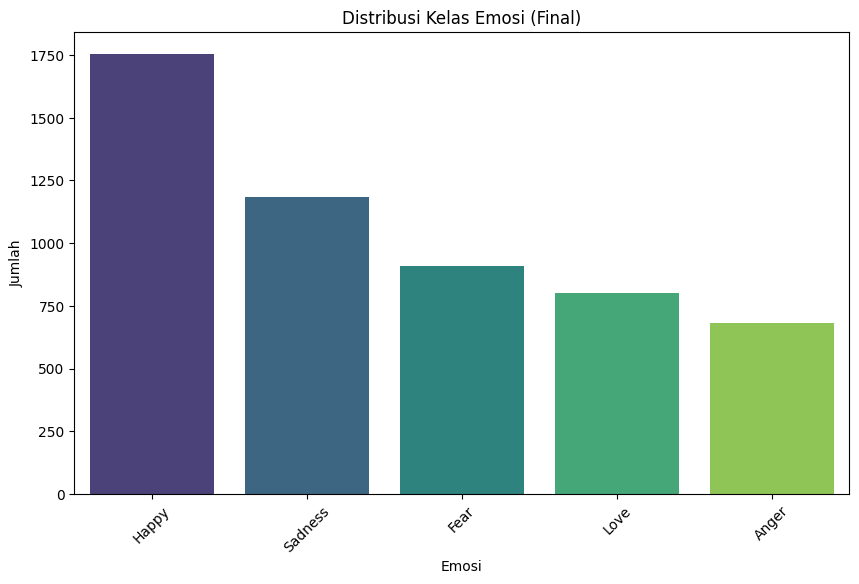

In [8]:
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Emotion'])

# Buat Tabel Mapping
mapping = {str(k): int(v) for k, v in zip(le.classes_, le.transform(le.classes_))}
mapping_df = pd.DataFrame(list(mapping.items()), columns=['Label', 'Encoding'])

print("Label Mapping:")
display(mapping_df)

# Visualisasi Distribusi Kelas Final
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Emotion', palette='viridis', order=df['Emotion'].value_counts().index)
plt.title("Distribusi Kelas Emosi (Final)")
plt.xlabel("Emosi")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()

## 9. Stratified Train-Test Split
Membagi data menjadi 80% Train dan 20% Test secara stratified.

**Rationale**: Stratified split digunakan karena dataset bersifat **imbalanced**. Teknik ini memastikan proporsi setiap kelas emosi tetap sama baik di subset data latih maupun data uji.

Jumlah Data Train: 4264
Jumlah Data Test : 1066


/tmp/ipykernel_13140/3691200739.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_train['Emotion'], ax=ax[0], palette='magma', order=df['Emotion'].value_counts().index)
/tmp/ipykernel_13140/3691200739.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_test['Emotion'], ax=ax[1], palette='magma', order=df['Emotion'].value_counts().index)


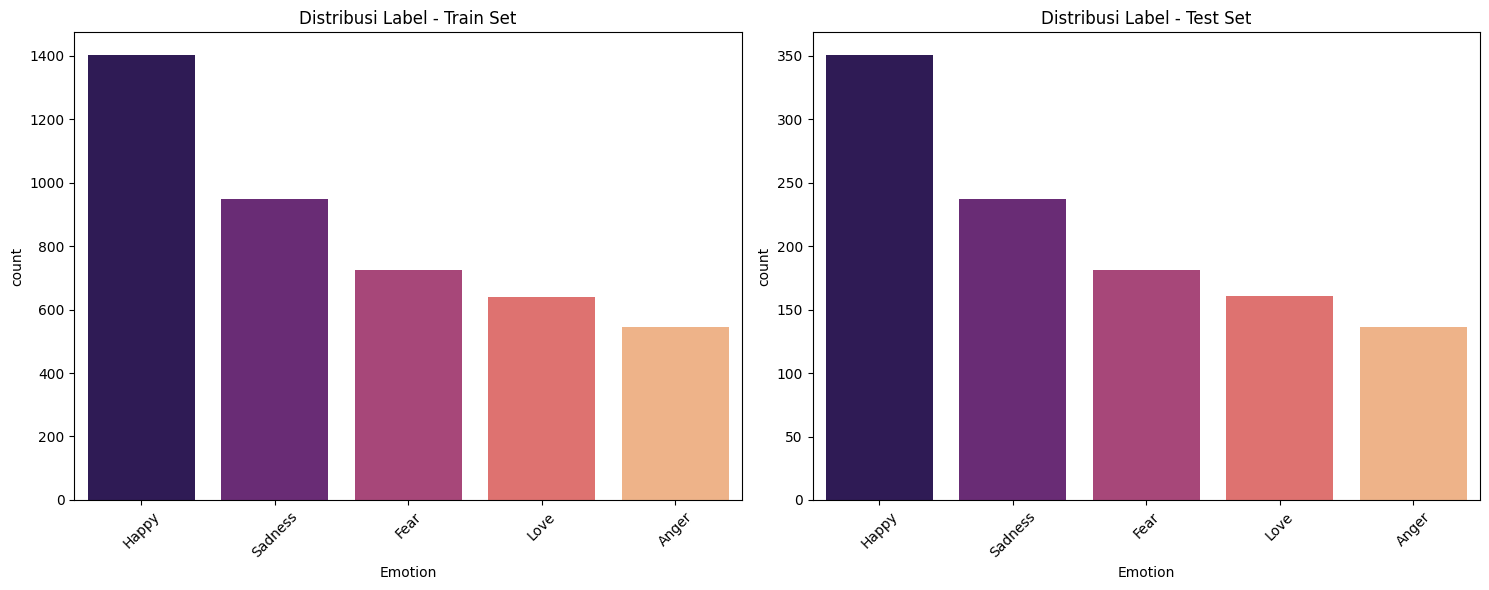

In [9]:
df_train, df_test = train_test_split(
    df, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['Label']
)

print(f"Jumlah Data Train: {len(df_train)}")
print(f"Jumlah Data Test : {len(df_test)}")

# Visualisasi Validasi Stratifikasi
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x=df_train['Emotion'], ax=ax[0], palette='magma', order=df['Emotion'].value_counts().index)
ax[0].set_title("Distribusi Label - Train Set")
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(x=df_test['Emotion'], ax=ax[1], palette='magma', order=df['Emotion'].value_counts().index)
ax[1].set_title("Distribusi Label - Test Set")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Experiment Summary & Save Outputs

In [10]:
# Buat directory processed jika belum ada
import os
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save Files
df.to_csv(f"{PROCESSED_DIR}/prdect_clean.csv", index=False)
df_train.to_csv(f"{PROCESSED_DIR}/prdect_train.csv", index=False)
df_test.to_csv(f"{PROCESSED_DIR}/prdect_test.csv", index=False)

# Save Label Mapping
with open(f"{PROCESSED_DIR}/prdect_label_mapping.json", "w") as f:
    json.dump(mapping, f)

print("--- Eksperimen Selesai ---")
print(f"Timestamp      : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total Data     : {len(df)}")
print(f"Data Train     : {len(df_train)}")
print(f"Data Test      : {len(df_test)}")
print(f"Random Seed    : {RANDOM_STATE}")
print(f"Output Saved to: {PROCESSED_DIR}")

--- Eksperimen Selesai ---
Timestamp      : 2026-05-11 19:17:05
Total Data     : 5330
Data Train     : 4264
Data Test      : 1066
Random Seed    : 42
Output Saved to: /content/drive/MyDrive/xai_lime_vs_shap/data/processed
